## Step 1: Import libraries
- Purpose: load TensorFlow/Keras, data utilities, and plotting tools.
- Why: we need these to load MNIST, build the ANN, and visualize results.
- Expected output: no printed output if imports succeed.

In [48]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers,Sequential
from tensorflow.keras.layers import Dense,Flatten

## Step 2: Load MNIST data
- Purpose: fetch train and test splits from Keras.
- Why: provides a standardized benchmark dataset.
- Expected output: four arrays (X_train, y_train, X_test, y_test).

In [49]:
(X_train,y_train),(X_test,y_test)=tf.keras.datasets.mnist.load_data()

## Step 3: Inspect training data shape
- Purpose: confirm number of samples and image dimensions.
- Why: ensures correct input shape for the model.
- Expected output: a shape like (60000, 28, 28).

In [50]:
X_train.shape

(60000, 28, 28)

## Step 4: Inspect a raw image array
- Purpose: view pixel values of a sample image.
- Why: understand raw intensity scale (0 to 255).
- Expected output: a 28x28 matrix of pixel values.

In [51]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 170,
        253, 253, 253, 253, 253, 225, 172, 253, 242, 195,  64,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  49, 238, 253, 253, 253, 253,
        253, 253, 253, 253, 251,  93,  82,  82,  56,  39,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  18, 219, 253, 253, 253, 253,
        253, 198, 182, 247, 241,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  80, 156, 107, 253, 253,
        205,  11,   0,  43, 154,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  14,   1, 154, 253,
         90,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 139, 253,
        190,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  11, 190,
        253,  70,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  35,
        241, 225, 160, 108,   1,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         81, 240, 253, 253, 119,  25,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  45, 186, 253, 253, 150,  27,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  16,  93, 252, 253, 187,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 249, 253, 249,  64,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  46, 130, 183, 253, 253, 207,   2,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  39,
        148, 229, 253, 253, 253, 250, 182,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  24, 114, 221,
        253, 253, 253, 253, 201,  78,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  23,  66, 213, 253, 253,
        253, 253, 198,  81,   2,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  18, 171, 219, 253, 253, 253, 253,
        195,  80,   9,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  55, 172, 226, 253, 253, 253, 253, 244, 133,
         11,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 136, 253, 25

## Step 5: Inspect test set shape
- Purpose: confirm test split size and dimensions.
- Why: validates the standard MNIST split.
- Expected output: a shape like (10000, 28, 28).

In [52]:
X_test.shape

(10000, 28, 28)

## Step 6: Inspect labels
- Purpose: view training labels.
- Why: confirm labels are integers 0-9.
- Expected output: an array of digit labels.

In [53]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

## Step 7: Visualize a sample digit
- Purpose: display an example image.
- Why: visually confirm the dataset content.
- Expected output: a grayscale digit image.

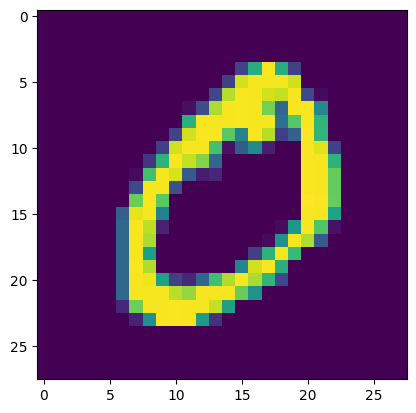

In [54]:
import matplotlib.pyplot as plt
plt.imshow(X_train[1])

## Step 8: Normalize pixel values
- Purpose: scale pixel intensities to [0, 1].
- Why: improves gradient stability and training speed.
- Expected output: X_train and X_test values in [0, 1].

In [55]:
X_train = X_train/255
X_test = X_test/255

## Step 9: Sanity check normalized data
- Purpose: verify the scaled values.
- Why: confirm normalization worked correctly.
- Expected output: array values between 0 and 1.

In [56]:
X_train

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

## Step 10: Define the ANN architecture
- Purpose: build a dense network for digit classification.
- Why: flattening converts images to vectors; dense layers learn global patterns.
- Expected output: a model object with Flatten and Dense layers.

In [57]:
model = Sequential()
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Step 11: Review model summary
- Purpose: confirm layer shapes and parameter counts.
- Why: ensures Flatten produces 784 inputs and output has 10 units.
- Expected output: a model summary table.

In [58]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## Step 12: Compile the model
- Purpose: set optimizer, loss, and metrics.
- Why: sparse categorical crossentropy matches integer labels.
- Expected output: no output if compilation succeeds.

In [59]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

## Step 13: Train the ANN
- Purpose: fit the model on training data with a validation split.
- Why: training learns weights; validation monitors generalization.
- Expected output: loss and accuracy per epoch.

In [60]:
history = model.fit(X_train,y_train,epochs=10,validation_split=0.25)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9169 - loss: 0.2886 - val_accuracy: 0.9502 - val_loss: 0.1709
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9621 - loss: 0.1316 - val_accuracy: 0.9637 - val_loss: 0.1227
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9731 - loss: 0.0903 - val_accuracy: 0.9659 - val_loss: 0.1117
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9794 - loss: 0.0675 - val_accuracy: 0.9663 - val_loss: 0.1109
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9845 - loss: 0.0515 - val_accuracy: 0.9697 - val_loss: 0.1054
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9878 - loss: 0.0405 - val_accuracy: 0.9719 - val_loss: 0.1036
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9905 - loss: 0.0312 - val_accuracy: 0.9755 - val_loss: 0.0916
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9926 - loss: 0.0248 -

## Step 14: Predict on the test set
- Purpose: generate class probabilities for each test image.
- Why: needed for accuracy and confusion matrix.
- Expected output: an array of probability vectors (shape: n x 10).

In [61]:
y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


## Step 15: Inspect raw predictions
- Purpose: view the probability vectors.
- Why: confirms softmax outputs sum to 1.
- Expected output: a numeric array of probabilities.

In [62]:
y_pred

array([[2.4106997e-10, 2.7072875e-09, 7.8565864e-07, ..., 9.9998206e-01,
        4.5316078e-08, 7.4848806e-08],
       [5.7919438e-09, 2.1838429e-07, 9.9999899e-01, ..., 5.8312010e-18,
        7.3046795e-07, 4.6823202e-11],
       [4.8640800e-08, 9.9907458e-01, 5.9031270e-04, ..., 2.1568096e-04,
        6.3205953e-05, 1.5887922e-07],
       ...,
       [3.1579142e-17, 5.8556214e-14, 9.4662886e-15, ..., 4.8118394e-09,
        7.2829931e-10, 1.0029720e-06],
       [5.1365863e-11, 1.7863522e-14, 5.1267097e-15, ..., 1.6311485e-11,
        1.7149338e-07, 1.6417186e-13],
       [6.6852359e-09, 7.9868268e-14, 2.5153450e-13, ..., 3.6491730e-18,
        1.4042043e-13, 1.5398779e-12]], dtype=float32)

## Step 16: Convert probabilities to labels
- Purpose: take the class with highest probability.
- Why: classification metrics expect discrete labels.
- Expected output: predicted digit labels.

In [63]:
y_pred.argmax(axis = 1)

array([7, 2, 1, ..., 4, 5, 6])

## Step 17: Compute accuracy and prepare metrics
- Purpose: import evaluation tools and compute accuracy.
- Why: accuracy summarizes overall performance.
- Expected output: an accuracy value.

In [64]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

accuracy_score(y_test,y_pred.argmax(axis = 1))



0.9787

## Step 18: Confusion matrix values
- Purpose: compute the confusion matrix.
- Why: shows which digits are confused with others.
- Expected output: a 10x10 matrix of counts.

In [65]:
confusion_matrix(y_test,y_pred.argmax(axis = 1))


array([[ 972,    1,    1,    1,    1,    0,    1,    1,    2,    0],
       [   0, 1128,    3,    0,    0,    1,    1,    1,    1,    0],
       [   6,    0, 1010,    1,    4,    0,    2,    6,    3,    0],
       [   2,    0,    3,  982,    0,    7,    0,    4,    7,    5],
       [   2,    0,    2,    1,  962,    0,    4,    3,    2,    6],
       [   4,    0,    0,    7,    1,  867,    6,    1,    5,    1],
       [   8,    3,    0,    0,    2,    3,  940,    0,    1,    1],
       [   1,    4,    7,    1,    1,    1,    0, 1006,    3,    4],
       [   9,    0,    5,    3,    1,    5,    1,    6,  942,    2],
       [   3,    4,    0,    3,    8,    4,    1,    7,    1,  978]])

## Step 19: Classification report
- Purpose: compute precision, recall, and F1 per digit.
- Why: accuracy alone can hide class-specific weaknesses.
- Expected output: a text report.

In [66]:
print(classification_report(y_test,y_pred.argmax(axis = 1)))


              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.97      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.97      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.98      0.98      1028
           8       0.97      0.97      0.97       974
           9       0.98      0.97      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



## Step 20: Plot confusion matrix heatmap
- Purpose: visualize confusion matrix counts.
- Why: heatmaps make error patterns easier to spot.
- Expected output: a heatmap plot.

<Axes: >

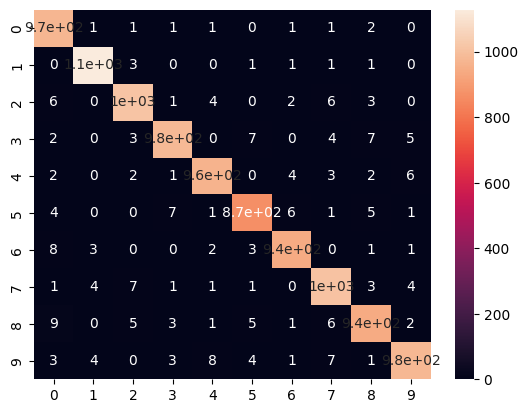

In [67]:
sns.heatmap(confusion_matrix(y_test,y_pred.argmax(axis = 1)),annot=True)

## Step 21: Plot loss curves
- Purpose: visualize training vs validation loss.
- Why: indicates convergence and potential overfitting.
- Expected output: a line plot of loss values.

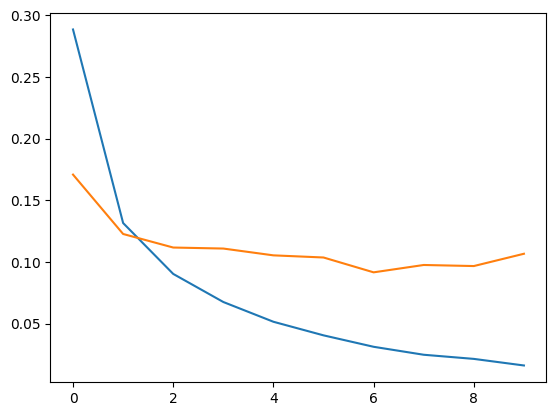

In [68]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

## Step 22: Plot accuracy curves
- Purpose: compare training and validation accuracy over epochs.
- Why: helps detect underfitting or overfitting.
- Expected output: a line plot of accuracy values.

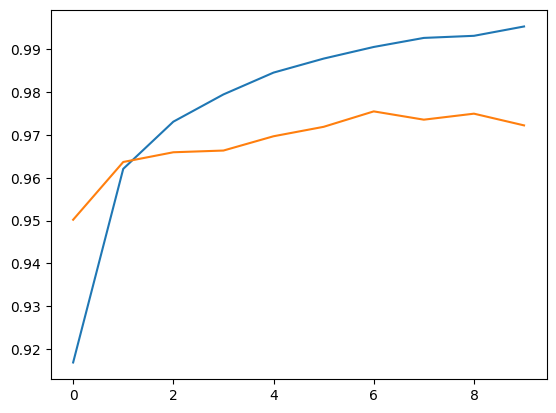

In [69]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

## Step 23: Visualize a test image
- Purpose: show a sample from the test set.
- Why: connect predictions to actual images.
- Expected output: a displayed digit image.

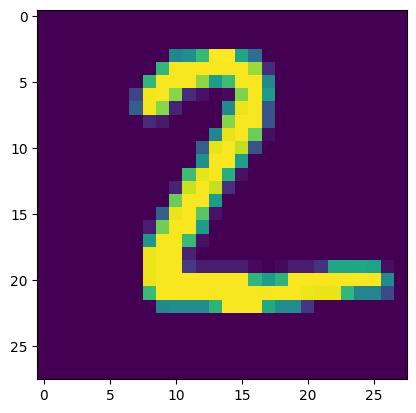

In [76]:
plt.imshow(X_test[1])

## Step 24: Predict a single image
- Purpose: run the model on one example and visualize the prediction.
- Why: demonstrates inference on a single sample.
- Expected output: a plotted image with a predicted digit title.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


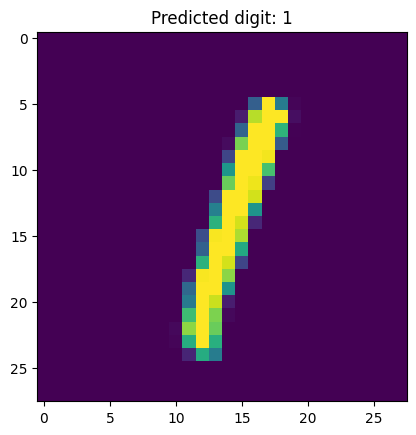

In [74]:
grp = model.predict(X_test[5].reshape(1,28,28)).argmax(axis=1)
plt.imshow(X_test[5])
plt.title(f'Predicted digit: {grp[0]}')
plt.show()